# Model Explainability & Interpretability
This notebook uses SHAP values and permutation features importance to explain the ensembled classifier. We look at global feature contributions, local trade decisions, and partial dependency curves.

In [1]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
import joblib
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import permutation_importance
import sys
import warnings
warnings.filterwarnings('ignore', category=UserWarning, message='.*feature names.*')
sys.path.append('../')
ROOT = Path.cwd().parent
CSV = ROOT / 'csv_files'
OUT = ROOT / 'outputs'
ART = ROOT / 'model_artifacts'
SEED = 42

## Load Champion Model & Validation Dataset

In [2]:
model = joblib.load(ART / 'final_calibrated_hgb_model.joblib')
features = pd.read_csv(ART / 'final_model_features.csv')['feature'].tolist()
df = pd.read_csv(ROOT / 'data' / 'holdout_data.csv')
X = df[features]
y = df['y'].values
print(f"Holdout dimensions: {X.shape}")

Holdout dimensions: (31662, 54)


## Compute SHAP Values
Since SHAP can be computationally intensive, we sample 500 rows randomly to capture representative attributions.

In [3]:
# We sample background and test instances for KernelExplainer
rng = np.random.default_rng(SEED)
idx_sample = rng.choice(len(X), size=200, replace=False)
X_sample = X.iloc[idx_sample].copy()

# For column transformations in pipeline, we extract numeric encoding
pre = model.estimator.base_models['xgb'].named_steps['pre']
X_sample_trans = pd.DataFrame(pre.transform(X_sample), columns=features)

# Fit explainer on meta predictions
def predict_fn(x_trans_array):
    # Construct pd.DataFrame to pass into pipeline estimators
    # We bypass the pre-processing transformer for base models since input is pre-transformed
    base_preds = []
    for name in ['xgb', 'lgbm', 'cat']:
        clf = model.estimator.base_models[name].named_steps['clf']
        base_preds.append(clf.predict_proba(x_trans_array)[:, 1])
    meta_features = np.column_stack(base_preds)
    p = model.estimator.meta_model.predict_proba(meta_features)[:, 1]
    return p

# Initialize background
bg = shap.kmeans(X_sample_trans, 5)
explainer = shap.KernelExplainer(predict_fn, bg)
shap_values = explainer.shap_values(X_sample_trans, nsamples=100)

print("SHAP computation complete.")

  0%|          | 0/200 [00:00<?, ?it/s]

SHAP computation complete.


## Plot SHAP Global Importance Summary

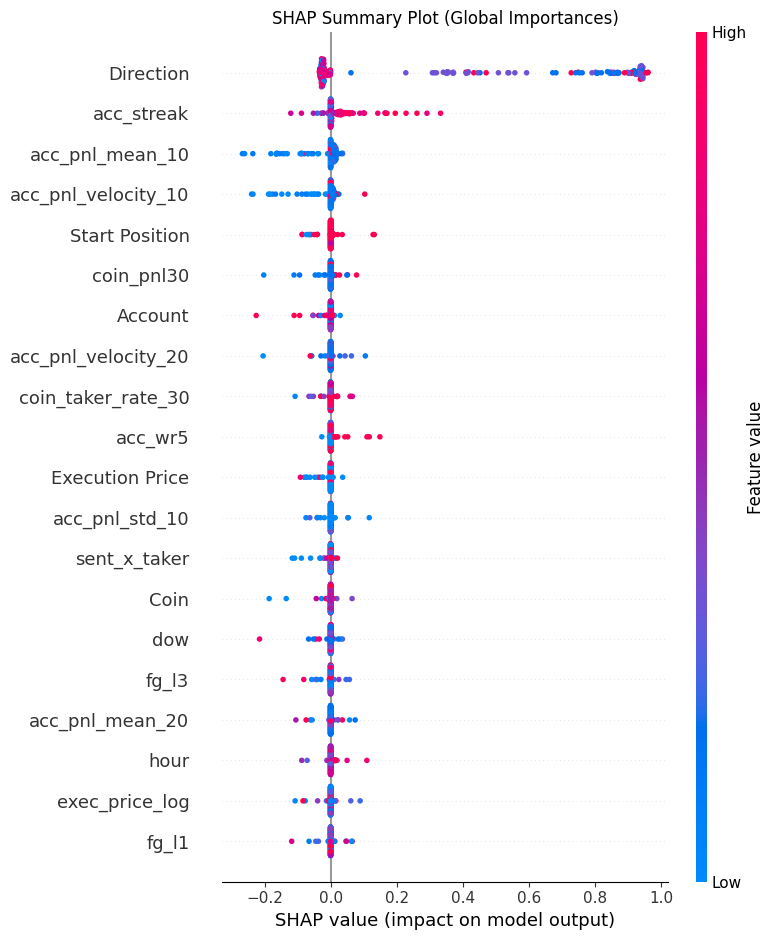

In [4]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample_trans, show=False)
plt.title('SHAP Summary Plot (Global Importances)')
plt.tight_layout()
plt.savefig(OUT / 'figures/shap_summary.png', dpi=180, bbox_inches='tight')
plt.show()

## Permutation Feature Importance
We also calculate permutation feature importance on the full holdout set to evaluate importance robustness.

/tmp/ipykernel_902548/620954109.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_df.head(15), x='importance_mean', y='feature', palette='viridis')


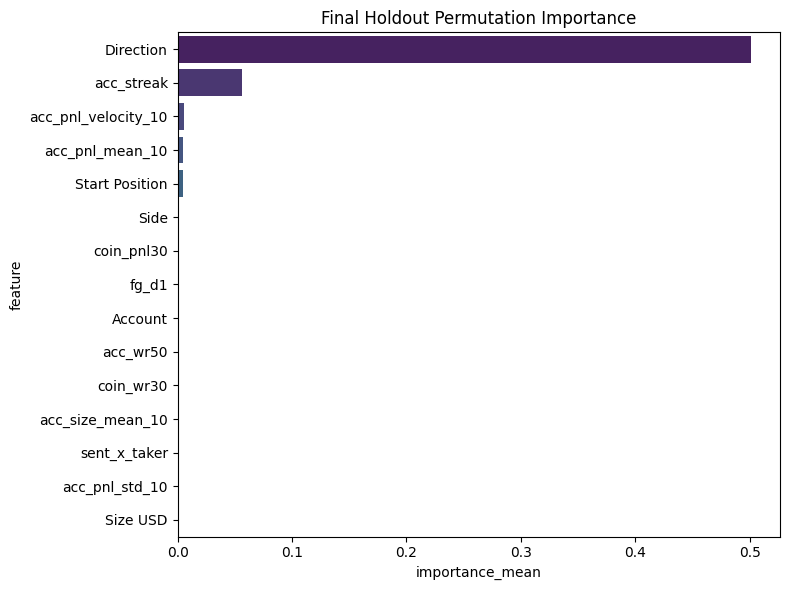

,feature,importance_mean,importance_std
52,Direction,0.501424,0.003580
33,acc_streak,0.056200,0.000930
20,acc_pnl_velocity_10,0.005543,0.000390
18,acc_pnl_mean_10,0.005039,0.000320
3,Start Position,0.004637,0.000296
51,Side,0.001611,0.000219
35,coin_pnl30,0.001183,0.000067
40,fg_d1,0.001084,0.000284
49,Account,0.001056,0.000139
16,acc_wr50,0.000808,0.000280


In [5]:
perm = permutation_importance(model, X, y, n_repeats=5, random_state=SEED, scoring='roc_auc', n_jobs=-1)
imp_df = pd.DataFrame({
    'feature': features,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std
}).sort_values('importance_mean', ascending=False)

imp_df.to_csv(CSV / 'final_holdout_feature_importance.csv', index=False)
imp_df.to_csv(ROOT / 'data' / 'final_holdout_feature_importance.csv', index=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=imp_df.head(15), x='importance_mean', y='feature', palette='viridis')
plt.title('Final Holdout Permutation Importance')
plt.tight_layout()
plt.savefig(OUT / 'figures/final_holdout_feature_importance.png', dpi=180, bbox_inches='tight')
plt.show()
imp_df.head(10)